<a href="https://colab.research.google.com/github/4551kiet-999/GOOGLE-PAGE-RANK-MINI/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

The user has exceeded their Drive storage quota
GapiError: The user has exceeded their Drive storage quota
    at new uL (https://ssl.gstatic.com/colaboratory-static/common/dbc2de5528be69dbe805bada26491703/external_binary.js:1764:911)
    at new rS (https://ssl.gstatic.com/colaboratory-static/common/dbc2de5528be69dbe805bada26491703/external_binary.js:2882:264)
    at new aT (https://ssl.gstatic.com/colaboratory-static/common/dbc2de5528be69dbe805bada26491703/external_binary.js:2927:581)
    at nJb (https://ssl.gstatic.com/colaboratory-static/common/dbc2de5528be69dbe805bada26491703/external_binary.js:2980:444)
    at https://ssl.gstatic.com/colaboratory-static/common/dbc2de5528be69dbe805bada26491703/external_binary.js:2989:286
    at Generator.throw (<anonymous>)
    at c (https://ssl.gstatic.com/colaboratory-static/common/dbc2de5528be69dbe805bada26491703/external_binary.js:6:76)

SyntaxError: invalid syntax (1928584065.py, line 1)

In [3]:

# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

# Make NumPy output easier to read
np.set_printoptions(precision=6, suppress=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:

# ============================================================
# INPUT CONFIGURATION
# ============================================================

# Names of the 5 web pages
pages = ["Page A", "Page B", "Page C", "Page D", "Page E"]

# Links:
# "Page A": ["Page B", "Page C"]
# means Page A has links to Page B and Page C.

links = {
    "Page A": ["Page B", "Page C"],
    "Page B": ["Page C", "Page D"],
    "Page C": ["Page A"],
    "Page D": ["Page C", "Page E"],
    "Page E": ["Page A", "Page C"]
}

# Power iteration settings
tolerance = 1e-12
max_iterations = 1000

# Starting probability distribution
# Equal probability for every page
initial_rank = np.ones(len(pages)) / len(pages)

print("Pages:")
for page in pages:
    print(" -", page)

print("\nLink structure:")
for page, destinations in links.items():
    print(f"{page} -> {', '.join(destinations)}")

Pages:
 - Page A
 - Page B
 - Page C
 - Page D
 - Page E

Link structure:
Page A -> Page B, Page C
Page B -> Page C, Page D
Page C -> Page A
Page D -> Page C, Page E
Page E -> Page A, Page C


In [6]:

# ============================================================
# INPUT VALIDATION
# ============================================================

# Check that all pages appearing in links actually exist
for source, destinations in links.items():

    if source not in pages:
        raise ValueError(f"{source} is not present in pages list.")

    for destination in destinations:
        if destination not in pages:
            raise ValueError(
                f"{destination} is not present in pages list."
            )

# Check that every page has at least one outgoing link
for page in pages:
    if len(links.get(page, [])) == 0:
        raise ValueError(
            f"{page} has no outgoing links. "
            "This first version assumes no dangling pages."
        )

print("Input validation successful.")

Input validation successful.


In [7]:

# ============================================================
# MATHEMATICAL MODEL — TRANSITION MATRIX
# ============================================================

n = len(pages)

# Create an n x n matrix
M = np.zeros((n, n))

# Convert page names to indices
page_index = {page: i for i, page in enumerate(pages)}

# Fill the transition matrix
for source in pages:

    source_index = page_index[source]
    destinations = links[source]

    # Equal probability for each outgoing link
    probability = 1 / len(destinations)

    for destination in destinations:

        destination_index = page_index[destination]

        # Row = destination
        # Column = source
        M[destination_index, source_index] = probability

print("Transition Matrix M:\n")
print(M)

print("\nColumn sums:")
print(M.sum(axis=0))

Transition Matrix M:

[[0.  0.  1.  0.  0.5]
 [0.5 0.  0.  0.  0. ]
 [0.5 0.5 0.  0.5 0.5]
 [0.  0.5 0.  0.  0. ]
 [0.  0.  0.  0.5 0. ]]

Column sums:
[1. 1. 1. 1. 1.]


In [8]:

# ============================================================
# PAGE RANK — POWER ITERATION
# ============================================================

def power_iteration(M, initial_rank, tolerance=1e-12, max_iterations=1000):
    """
    Find the steady-state PageRank vector using power iteration.

    Mathematical operation:

        r_new = M @ r_old

    The process stops when the change becomes smaller
    than the specified tolerance.
    """

    rank = initial_rank.copy()

    history = [rank.copy()]

    for iteration in range(1, max_iterations + 1):

        new_rank = M @ rank

        # Measure the total change
        difference = np.linalg.norm(new_rank - rank, ord=1)

        history.append(new_rank.copy())

        # Check convergence
        if difference < tolerance:
            return new_rank, iteration, np.array(history)

        rank = new_rank

    return rank, max_iterations, np.array(history)


# Run the algorithm
pagerank, iterations, history = power_iteration(
    M,
    initial_rank,
    tolerance,
    max_iterations
)

print("Power iteration completed.")
print("Iterations:", iterations)
print("PageRank vector:")
print(pagerank)

Power iteration completed.
Iterations: 46
PageRank vector:
[0.355556 0.177778 0.333333 0.088889 0.044444]


In [9]:

# ============================================================
# ITERATION TABLE
# ============================================================

iteration_table = pd.DataFrame(
    history,
    columns=pages
)

iteration_table.index.name = "Iteration"

display(
    iteration_table.head(10).style.format("{:.6f}")
)

print("...")
print(f"Total iterations required: {iterations}")

,Page A,Page B,Page C,Page D,Page E
Iteration,,,,,
0,0.200000,0.200000,0.200000,0.200000,0.200000
1,0.300000,0.100000,0.400000,0.100000,0.100000
2,0.450000,0.150000,0.300000,0.050000,0.050000
3,0.325000,0.225000,0.350000,0.075000,0.025000
4,0.362500,0.162500,0.325000,0.112500,0.037500
5,0.343750,0.181250,0.337500,0.081250,0.056250
6,0.365625,0.171875,0.331250,0.090625,0.040625
7,0.351562,0.182813,0.334375,0.085938,0.045313
8,0.357031,0.175781,0.332813,0.091406,0.042969


...
Total iterations required: 46


In [10]:

# ============================================================
# FINAL PAGERANK RESULTS
# ============================================================

result = pd.DataFrame({
    "Page": pages,
    "PageRank": pagerank
})

# Sort from most important to least important
result = result.sort_values(
    by="PageRank",
    ascending=False
).reset_index(drop=True)

# Add percentage
result["Percentage"] = result["PageRank"] * 100

print("FINAL PAGERANK")
display(
    result.style.format({
        "PageRank": "{:.6f}",
        "Percentage": "{:.2f}%"
    })
)

most_important = result.iloc[0]["Page"]

print("\nMost important page:", most_important)
print(
    f"PageRank = {result.iloc[0]['PageRank']:.6f}"
)

FINAL PAGERANK


,Page,PageRank,Percentage
0,Page A,0.355556,35.56%
1,Page C,0.333333,33.33%
2,Page B,0.177778,17.78%
3,Page D,0.088889,8.89%
4,Page E,0.044444,4.44%



Most important page: Page A
PageRank = 0.355556


In [11]:

# ============================================================
# EIGENVALUE = 1 VERIFICATION
# ============================================================

M_times_rank = M @ pagerank

eigen_check = pd.DataFrame({
    "Page": pages,
    "PageRank r": pagerank,
    "M @ r": M_times_rank,
    "Difference": M_times_rank - pagerank
})

display(
    eigen_check.style.format({
        "PageRank r": "{:.10f}",
        "M @ r": "{:.10f}",
        "Difference": "{:.2e}"
    })
)

print("\nMaximum numerical error:",
      np.max(np.abs(M_times_rank - pagerank)))

,Page,PageRank r,M @ r,Difference
0,Page A,0.3555555556,0.3555555556,-6.97e-14
1,Page B,0.1777777778,0.1777777778,6.68e-14
2,Page C,0.3333333333,0.3333333333,2.89e-15
3,Page D,0.0888888889,0.0888888889,-6.11e-14
4,Page E,0.0444444444,0.0444444444,6.11e-14



Maximum numerical error: 6.966649479522857e-14


In [12]:

# ============================================================
# NUMPY EIGENVALUE VERIFICATION
# ============================================================

eigenvalues, eigenvectors = np.linalg.eig(M)

# Find the eigenvalue closest to 1
index = np.argmin(np.abs(eigenvalues - 1))

lambda_one = eigenvalues[index]
eigenvector_one = np.real(eigenvectors[:, index])

# Normalize the eigenvector so that its elements sum to 1
eigenvector_one = eigenvector_one / np.sum(eigenvector_one)

# Make the direction positive if necessary
if eigenvector_one.sum() < 0:
    eigenvector_one = -eigenvector_one

print("Eigenvalue closest to 1:")
print(lambda_one)

print("\nCorresponding normalized eigenvector:")
print(eigenvector_one)

print("\nPower iteration PageRank:")
print(pagerank)

print("\nMaximum difference:")
print(
    np.max(
        np.abs(eigenvector_one - pagerank)
    )
)

Eigenvalue closest to 1:
(0.9999999999999987+0j)

Corresponding normalized eigenvector:
[0.355556 0.177778 0.333333 0.088889 0.044444]

Power iteration PageRank:
[0.355556 0.177778 0.333333 0.088889 0.044444]

Maximum difference:
4.7128967395337895e-14


In [13]:

# ============================================================
# SYMPY SYMBOLIC VERIFICATION
# ============================================================

M_sym = sp.Matrix(M)

# Calculate eigenvectors/eigenvalues symbolically
eigen_data = M_sym.eigenvects()

print("Eigenvalue information:\n")

for eigenvalue, multiplicity, vectors in eigen_data:
    print("Eigenvalue:", eigenvalue)
    print("Multiplicity:", multiplicity)

    for vector in vectors:
        print("Eigenvector:")
        sp.pprint(vector)

    print("-" * 50)

Eigenvalue information:

Eigenvalue: 1.0 + 4.09983192343169e-65*I
Multiplicity: 1
Eigenvector:
⎡ -0.0337820047123469 + 0.672276818944665⋅ⅈ ⎤
⎢                                           ⎥
⎢ -0.0168910023561735 + 0.336138409472333⋅ⅈ ⎥
⎢                                           ⎥
⎢ -0.0316706294178253 + 0.630259517760624⋅ⅈ ⎥
⎢                                           ⎥
⎢-0.00844550117808674 + 0.168069204736166⋅ⅈ ⎥
⎢                                           ⎥
⎣-0.00422275058904337 + 0.0840346023680832⋅ⅈ⎦
--------------------------------------------------
Eigenvalue: 1.69860153934608e-64 - 0.5*I
Multiplicity: 1
Eigenvector:
⎡   0.406264023317825 - 0.326472293988677⋅ⅈ   ⎤
⎢                                             ⎥
⎢   0.326472293988677 + 0.406264023317825⋅ⅈ   ⎥
⎢                                             ⎥
⎢2.01887018592811e-64 + 4.84482449902943e-65⋅ⅈ⎥
⎢                                             ⎥
⎢  -0.406264023317825 + 0.326472293988677⋅ⅈ   ⎥
⎢                                 

In [14]:

# ============================================================
# EXACT MATRIX FOR MATHEMATICAL PRESENTATION
# ============================================================

M_exact = sp.Matrix([
    [0,   0,   1,   0,   sp.Rational(1, 2)],
    [sp.Rational(1, 2), 0, 0, 0, 0],
    [sp.Rational(1, 2), sp.Rational(1, 2), 0,
     sp.Rational(1, 2), sp.Rational(1, 2)],
    [0, sp.Rational(1, 2), 0, 0, 0],
    [0, 0, 0, sp.Rational(1, 2), 0]
])

print("Exact transition matrix:")
sp.pprint(M_exact)

print("\nEigenvalues:")
print(M_exact.eigenvals())

Exact transition matrix:
⎡ 0    0   1   0   1/2⎤
⎢                     ⎥
⎢1/2   0   0   0    0 ⎥
⎢                     ⎥
⎢1/2  1/2  0  1/2  1/2⎥
⎢                     ⎥
⎢ 0   1/2  0   0    0 ⎥
⎢                     ⎥
⎣ 0    0   0  1/2   0 ⎦

Eigenvalues:
{1: 1, -1/2: 2, -I/2: 1, I/2: 1}


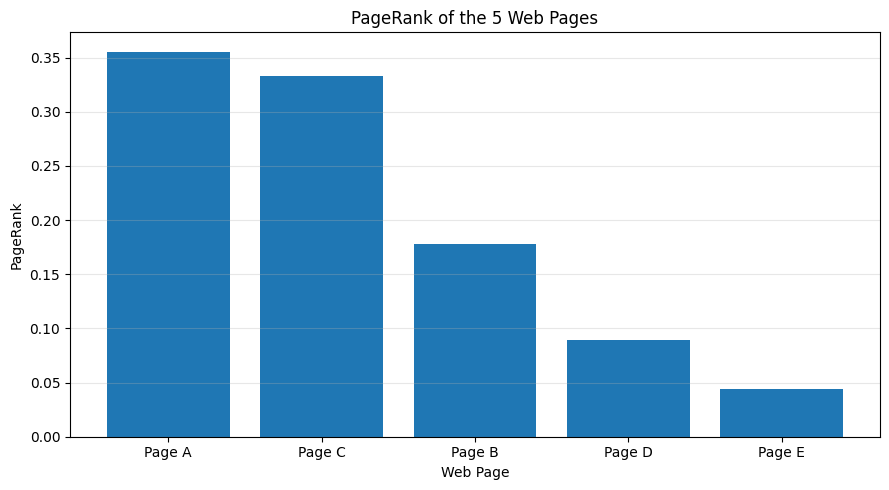

In [15]:

# ============================================================
# CHART 1 — FINAL PAGERANK
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    result["Page"],
    result["PageRank"]
)

plt.title("PageRank of the 5 Web Pages")
plt.xlabel("Web Page")
plt.ylabel("PageRank")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

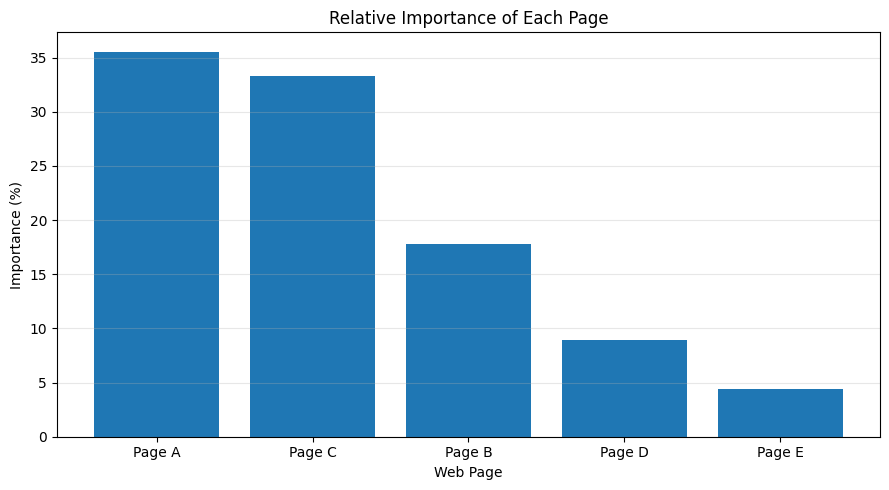

In [16]:

# ============================================================
# CHART 2 — IMPORTANCE PERCENTAGE
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    result["Page"],
    result["Percentage"]
)

plt.title("Relative Importance of Each Page")
plt.xlabel("Web Page")
plt.ylabel("Importance (%)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

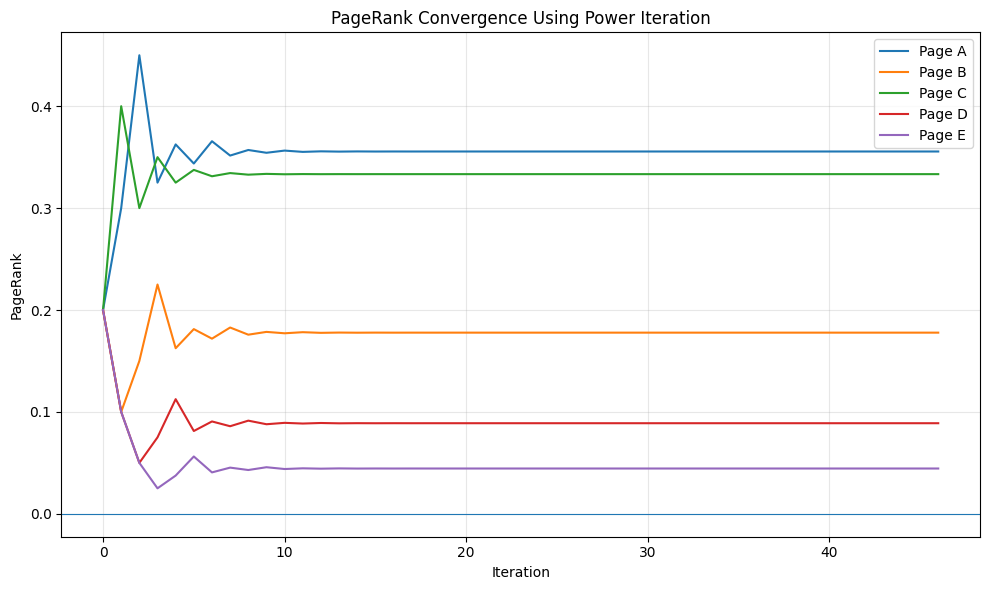

In [17]:

# ============================================================
# CHART 3 — POWER ITERATION CONVERGENCE
# ============================================================

plt.figure(figsize=(10, 6))

for i, page in enumerate(pages):
    plt.plot(
        history[:, i],
        label=page
    )

plt.axhline(
    0,
    linewidth=0.8
)

plt.title("PageRank Convergence Using Power Iteration")
plt.xlabel("Iteration")
plt.ylabel("PageRank")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

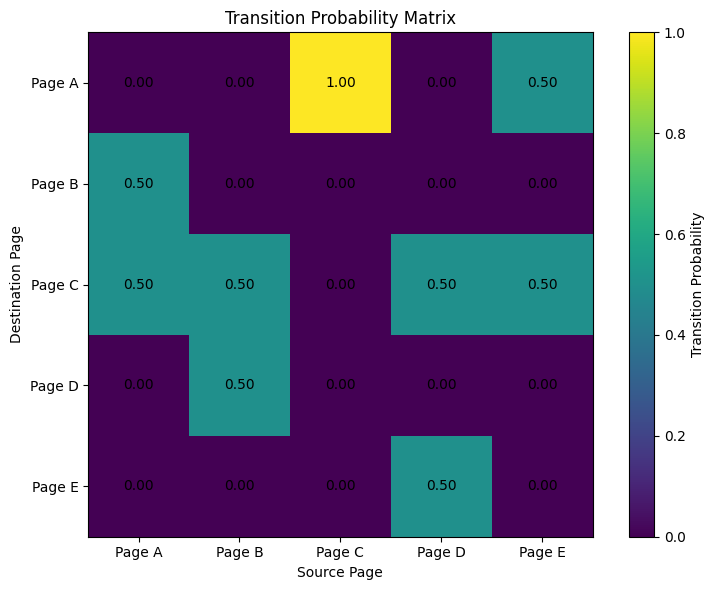

In [18]:

# ============================================================
# CHART 4 — TRANSITION MATRIX HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(
    M,
    interpolation="nearest"
)

plt.colorbar(label="Transition Probability")

plt.xticks(
    range(n),
    pages
)

plt.yticks(
    range(n),
    pages
)

plt.title("Transition Probability Matrix")

plt.xlabel("Source Page")
plt.ylabel("Destination Page")

# Add probability values inside cells
for i in range(n):
    for j in range(n):
        plt.text(
            j,
            i,
            f"{M[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

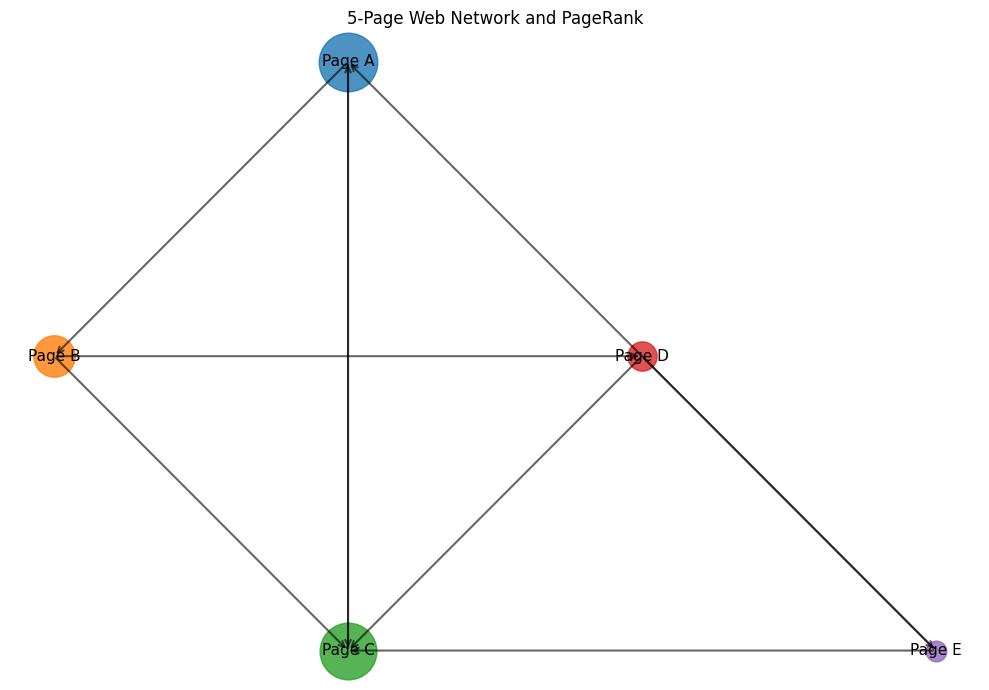

In [19]:

# ============================================================
# CHART 5 — WEB LINK NETWORK
# ============================================================

# We use fixed coordinates so that the diagram is reproducible.

positions = {
    "Page A": (0, 1),
    "Page B": (-1, 0),
    "Page C": (0, -1),
    "Page D": (1, 0),
    "Page E": (2, -1)
}

plt.figure(figsize=(10, 7))

# Draw links
for source, destinations in links.items():

    x1, y1 = positions[source]

    for destination in destinations:

        x2, y2 = positions[destination]

        plt.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.5,
                alpha=0.6
            )
        )

# Scale node size according to PageRank
node_sizes = {
    page: 5000 * pagerank[page_index[page]]
    for page in pages
}

# Draw pages
for page in pages:

    x, y = positions[page]

    plt.scatter(
        x,
        y,
        s=node_sizes[page],
        alpha=0.8
    )

    plt.text(
        x,
        y,
        page,
        ha="center",
        va="center",
        fontsize=11
    )

plt.title("5-Page Web Network and PageRank")
plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:

# ============================================================
# BENCHMARK TEST DATASET
# ============================================================

benchmark_expected = np.array([
    0.3555555556,  # Page A
    0.1777777778,  # Page B
    0.3333333333,  # Page C
    0.0888888889,  # Page D
    0.0444444444   # Page E
])

benchmark_error = np.max(
    np.abs(pagerank - benchmark_expected)
)

print("Benchmark PageRank:")
print(benchmark_expected)

print("\nCalculated PageRank:")
print(pagerank)

print("\nMaximum benchmark error:")
print(benchmark_error)

if benchmark_error < 1e-8:
    print("\n✓ BENCHMARK PASSED")
else:
    print("\n✗ BENCHMARK FAILED")

Benchmark PageRank:
[0.355556 0.177778 0.333333 0.088889 0.044444]

Calculated PageRank:
[0.355556 0.177778 0.333333 0.088889 0.044444]

Maximum benchmark error:
4.440307843633917e-11

✓ BENCHMARK PASSED


In [21]:

# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 60)
print("GOOGLE PAGERANK MINI PROJECT — FINAL RESULT")
print("=" * 60)

print(f"Number of pages: {len(pages)}")
print(f"Power iterations: {iterations}")
print(f"Convergence tolerance: {tolerance}")

print("\nPageRank Results:")
print("-" * 60)

for rank, row in result.iterrows():

    print(
        f"{rank + 1}. {row['Page']:8s} "
        f"PageRank = {row['PageRank']:.6f} "
        f"({row['Percentage']:.2f}%)"
    )

print("-" * 60)

print(
    f"\nMost important page: {most_important}"
)

print(
    "\nMathematical condition:"
)

print(
    "M × r = r"
)

print(
    "Therefore, r is an eigenvector of M "
    "corresponding to eigenvalue λ = 1."
)

print("\n✓ Project completed successfully.")

GOOGLE PAGERANK MINI PROJECT — FINAL RESULT
Number of pages: 5
Power iterations: 46
Convergence tolerance: 1e-12

PageRank Results:
------------------------------------------------------------
1. Page A   PageRank = 0.355556 (35.56%)
2. Page C   PageRank = 0.333333 (33.33%)
3. Page B   PageRank = 0.177778 (17.78%)
4. Page D   PageRank = 0.088889 (8.89%)
5. Page E   PageRank = 0.044444 (4.44%)
------------------------------------------------------------

Most important page: Page A

Mathematical condition:
M × r = r
Therefore, r is an eigenvector of M corresponding to eigenvalue λ = 1.

✓ Project completed successfully.


In [24]:

# ================================================================
# GOOGLE PAGERANK MINI PROJECT (B2)
# Complete One-Cell Anti-Bug Version
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=8, suppress=True)


# ================================================================
# 1. USER INPUT / CONFIGURATION
# ================================================================

pages = [
    "Page A",
    "Page B",
    "Page C",
    "Page D",
    "Page E"
]

# Web links
# Source page -> pages it links to
links = {
    "Page A": ["Page B", "Page C"],
    "Page B": ["Page C", "Page D"],
    "Page C": ["Page A"],
    "Page D": ["Page C", "Page E"],
    "Page E": ["Page A", "Page C"]
}

TOLERANCE = 1e-12
MAX_ITERATIONS = 1000


# ================================================================
# 2. INPUT VALIDATION
# ================================================================

if len(pages) != 5:
    raise ValueError("ERROR: Exactly 5 pages are required.")

if len(set(pages)) != len(pages):
    raise ValueError("ERROR: Duplicate page names found.")

for page in pages:

    if page not in links:
        raise ValueError(
            f"ERROR: No links specified for {page}."
        )

    destinations = links[page]

    if not isinstance(destinations, list):
        raise TypeError(
            f"ERROR: Links for {page} must be a list."
        )

    if len(destinations) == 0:
        raise ValueError(
            f"ERROR: {page} has no outgoing links."
        )

    if len(destinations) != len(set(destinations)):
        raise ValueError(
            f"ERROR: Duplicate links found for {page}."
        )

    for destination in destinations:

        if destination not in pages:
            raise ValueError(
                f"ERROR: {page} links to unknown page "
                f"{destination}."
            )


# ================================================================
# 3. CREATE TRANSITION MATRIX
# ================================================================

n = len(pages)

page_index = {
    page: i for i, page in enumerate(pages)
}

M = np.zeros((n, n), dtype=float)

for source in pages:

    source_index = page_index[source]

    destinations = links[source]

    probability = 1.0 / len(destinations)

    for destination in destinations:

        destination_index = page_index[destination]

        # Row = destination
        # Column = source
        M[destination_index, source_index] = probability


# ================================================================
# 4. MATRIX VALIDATION
# ================================================================

if M.shape != (n, n):
    raise ValueError("ERROR: Transition matrix is not square.")

if not np.all(np.isfinite(M)):
    raise ValueError(
        "ERROR: Matrix contains NaN or infinite values."
    )

if np.any(M < 0):
    raise ValueError(
        "ERROR: Negative transition probability found."
    )

if not np.allclose(
    M.sum(axis=0),
    1.0,
    atol=1e-12
):
    raise ValueError(
        "ERROR: Matrix columns must sum to 1."
    )


# ================================================================
# 5. POWER ITERATION
#
# Mathematical equation:
#
#       r(new) = M × r(old)
#
# At steady state:
#
#       M × r = r
#
# Therefore:
#
#       M × r = 1 × r
#
# So PageRank is the eigenvector corresponding to
# eigenvalue λ =